In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [15]:
base = '../../depth_exps/DINOV2/dinov2_l14/Linear_layer/NYU/'
K_RANK = 4 
V_vectors = {}
experiment_labels = []

def extract_layer_info(log_path):
    with open(log_path, 'r') as f:
        lines = f.readlines()
        if len(lines) >= 12:
            target_line = lines[11].strip() 
            if 'layer:' in target_line:
                parts = target_line.split(':')
                if len(parts) > 1:
                    return int(parts[1].strip().split()[0])
    return -1 


for file in sorted(os.listdir(base)):
    if file != '.ipynb_checkpoints' and os.path.isdir(os.path.join(base, file)):
        
        ckpt_path = os.path.join(base, file, 'ckpt.pth')
        log_path = os.path.join(base, file, 'training.log')
        
        layer = extract_layer_info(log_path)
        
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            
        W = ckpt["probe"]["head.conv.weight"] 
        W_mat = W.view(W.shape[0], -1)  
        D = W_mat.shape[1]
        _, _, Vh = torch.linalg.svd(W_mat, full_matrices=False)
        V_k = Vh[:K_RANK].T.contiguous().float() 
        
        label = f"Layer_{layer}"
        experiment_labels.append(label)
        V_vectors[label] = V_k
            


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 3100.86it/s]


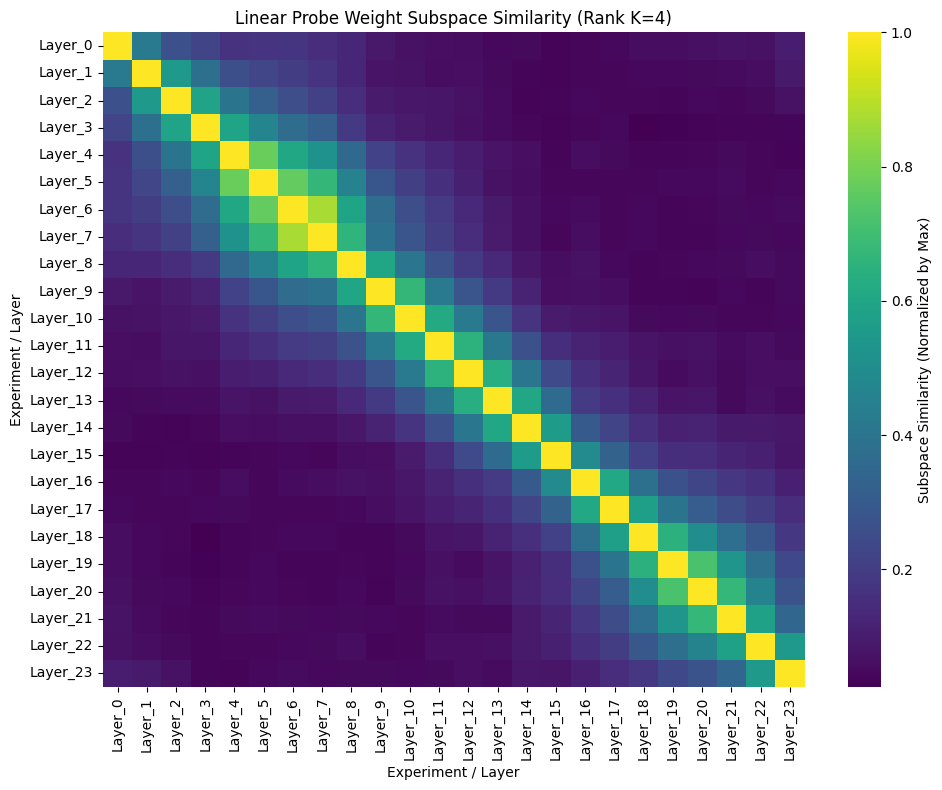

In [18]:
num_exps = len(experiment_labels)

similarity_matrix = np.zeros((num_exps, num_exps))
for i in tqdm(range(num_exps)):
    for j in range(num_exps):
        label_i = experiment_labels[i]
        label_j = experiment_labels[j]
        
        V_i = V_vectors[label_i]
        V_j = V_vectors[label_j]

        s = torch.linalg.svd(V_i.T @ V_j).S 
        average_cosine_similarity = torch.mean(s).item()
        
        similarity_matrix[i, j] = average_cosine_similarity

max_sim = similarity_matrix.max()
normalized_similarity_matrix = similarity_matrix / max_sim

plt.figure(figsize=(10, 8))

sns.heatmap(
    normalized_similarity_matrix,
    annot=False, 
    fmt=".4f",
    cmap="viridis", # 选择颜色主题
    xticklabels=experiment_labels,
    yticklabels=experiment_labels,
    cbar_kws={'label': f'Subspace Similarity (Normalized by Max)'}
)
plt.title(f"Linear Probe Weight Subspace Similarity (Rank K={K_RANK})")
plt.xlabel("Experiment / Layer")
plt.ylabel("Experiment / Layer")
plt.tight_layout()
plt.show()


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def interpolate(x, scale_factor, mode="bilinear", align_corners=True):
    return F.interpolate(x, scale_factor=scale_factor, mode=mode, align_corners=align_corners)

class ResidualConvUnit(nn.Module):
    def __init__(self, features, kernel_size):
        super().__init__()
        assert kernel_size % 1 == 0, "Kernel size needs to be odd"
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv2d(features, features, kernel_size, padding=padding),
            nn.ReLU(True),
            nn.Conv2d(features, features, kernel_size, padding=padding),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.conv(x) + x
        
class FeatureFusionBlock(nn.Module):
    def __init__(self, features, kernel_size, with_skip=True):
        super().__init__()
        self.with_skip = with_skip
        if self.with_skip:
            self.resConfUnit1 = ResidualConvUnit(features, kernel_size)

        self.resConfUnit2 = ResidualConvUnit(features, kernel_size)

    def forward(self, x, skip_x=None):
        if skip_x is not None:
            assert self.with_skip and skip_x.shape == x.shape
            x = self.resConfUnit1(x) + skip_x

        x = self.resConfUnit2(x)
        return x

class FourierPosEnc(nn.Module):
    def __init__(self, num_bands=6, max_freq=64.0):
        super().__init__()
        self.num_bands = num_bands
        self.max_freq = max_freq

    def forward(self, coords):
        """
        coords: [B, N, 2] in [-1, 1]
        return: [B, N, 4*num_bands]  (sin/cos for x,y)
        """
        B, N, _ = coords.shape
        device = coords.device
        freqs = torch.logspace(0, torch.log10(torch.tensor(self.max_freq, device=device)), self.num_bands)
        # [num_bands] -> [1,1,num_bands]
        freqs = freqs.view(1, 1, -1)

        x = coords[..., 0:1]  # [B,N,1]
        y = coords[..., 1:2]

        xb = x * freqs * torch.pi
        yb = y * freqs * torch.pi

        enc = torch.cat([torch.sin(xb), torch.cos(xb), torch.sin(yb), torch.cos(yb)], dim=-1)  # [B,N,4*num_bands]
        return enc


class DPTFeatureNet(nn.Module):
    """
    DPT-style multi-scale fusion, but outputs a fused feature map (hidden_dim channels),
    not a depth map.
    """
    def __init__(self, input_dims, hidden_dim=512, kernel_size=3):
        super().__init__()
        assert len(input_dims) == 4
        self.conv_0 = nn.Conv2d(input_dims[0], hidden_dim, 1, padding=0)
        self.conv_1 = nn.Conv2d(input_dims[1], hidden_dim, 1, padding=0)
        self.conv_2 = nn.Conv2d(input_dims[2], hidden_dim, 1, padding=0)
        self.conv_3 = nn.Conv2d(input_dims[3], hidden_dim, 1, padding=0)

        self.ref_0 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_1 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_2 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_3 = FeatureFusionBlock(hidden_dim, kernel_size, with_skip=False)

        # optional: keep a light embedding conv
        self.embed = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU(True),
        )

    def forward(self, feats):
        assert len(feats) == 4

        feats = [
            self.conv_0(feats[0]),
            self.conv_1(feats[1]),
            self.conv_2(feats[2]),
            self.conv_3(feats[3]),
        ]

        # match DPT: upsample each level to a common scale (simple version)
        feats = [interpolate(x, scale_factor=2) for x in feats]

        out = self.ref_3(feats[3], None)
        out = self.ref_2(feats[2], out)
        out = self.ref_1(feats[1], out)
        out = self.ref_0(feats[0], out)

        # bring to a moderately high resolution feature map
        out = interpolate(out, scale_factor=4)
        out = self.embed(out)
        # out: [B, hidden_dim, H', W']
        return out
        
class RankAdaptiveFieldHead(nn.Module):
    """
    Query depth as an implicit field conditioned on fused DPT features.

    - Sample local feature v(x) from fused feature map using grid_sample
    - Project to geometry subspace: z = v @ U  (U from probe SVD; fixed or learnable)
    - Predict rank r(x), build soft mask w(r), apply: z_masked = z * w
    - Decode depth with an MLP
    """
    def __init__(
        self,
        feat_dim=512,
        k_max=64,
        pos_bands=6,
        tau=0.5,
        hidden=256,
        use_fixed_U=True,
    ):
        super().__init__()
        self.k_max = k_max
        self.tau = tau
        self.posenc = FourierPosEnc(num_bands=pos_bands, max_freq=64.0)

        self.U = nn.Parameter(torch.randn(feat_dim, k_max) * 0.02, requires_grad=not use_fixed_U)

        rank_in_dim = feat_dim + 4 * pos_bands
        self.rank_mlp = nn.Sequential(
            nn.Linear(rank_in_dim, hidden),
            nn.ReLU(True),
            nn.Linear(hidden, 1),
        )

        dec_in_dim = k_max + 4 * pos_bands
        self.depth_mlp = nn.Sequential(
            nn.Linear(dec_in_dim, hidden),
            nn.ReLU(True),
            nn.Linear(hidden, hidden),
            nn.ReLU(True),
            nn.Linear(hidden, 1),
        )

    @staticmethod
    def _sample_feat_map(feat_map, coords):
        """
        feat_map: [B, C, H, W]
        coords: [B, N, 2] in [-1, 1], (x,y)
        return: sampled feats [B, N, C]
        """
        B, C, H, W = feat_map.shape
        # grid_sample expects grid [B, H_out, W_out, 2]
        grid = coords.view(B, -1, 1, 2)  # [B, N, 1, 2]
        sampled = F.grid_sample(feat_map, grid, mode="bilinear", align_corners=True)  # [B,C,N,1]
        sampled = sampled.squeeze(-1).permute(0, 2, 1).contiguous()  # [B,N,C]
        return sampled

    def _soft_rank_mask(self, r):
        """
        r: [B, N, 1], continuous rank
        return mask: [B, N, k_max] with monotonic property (first dims more likely kept)
        """
        device = r.device
        idx = torch.arange(1, self.k_max + 1, device=device).view(1, 1, -1)  # [1,1,k]
        # w_i = sigmoid((r - i)/tau)
        w = torch.sigmoid((r - idx) / self.tau)
        return w

    def forward(self, feat_map, coords):
        """
        feat_map: [B, C, H, W] from DPTFeatureNet
        coords:   [B, N, 2] in [-1,1]
        return:
            depth: [B, N, 1]
            aux: dict with rank and mask (optional)
        """
        v = self._sample_feat_map(feat_map, coords)  # [B,N,C]
        pe = self.posenc(coords)                     # [B,N,P]

        r_raw = self.rank_mlp(torch.cat([v, pe], dim=-1))          # [B,N,1]
        r = torch.sigmoid(r_raw) * float(self.k_max)               # [B,N,1] in [0,k_max]
        mask = self._soft_rank_mask(r)                              # [B,N,k]

        # project to k_max geometry directions
        z = v @ self.U                                              # [B,N,k]
        z = z * mask                                                # [B,N,k]

        # depth decode
        d = self.depth_mlp(torch.cat([z, pe], dim=-1))              # [B,N,1]
        return d, {"rank": r, "mask": mask}

class DPTImplicitDepth(nn.Module):
    def __init__(self, input_dims, hidden_dim=512, k_max=64, pos_bands=6, tau=0.5):
        super().__init__()
        self.feat_net = DPTFeatureNet(input_dims, hidden_dim=hidden_dim)
        self.field = RankAdaptiveFieldHead(
            feat_dim=hidden_dim,
            k_max=k_max,
            pos_bands=pos_bands,
            tau=tau,
            hidden=256,
            use_fixed_U=False, 
        )

    def forward(self, feats, coords):
        feat_map = self.feat_net(feats)      # [B,hidden,H',W']
        depth, aux = self.field(feat_map, coords)
        return depth, aux

    @torch.no_grad()
    def predict_dense(self, feats, H, W):
        """
        produce a dense depth map by querying a full grid.
        """
        B = feats[0].shape[0]
        ys, xs = torch.meshgrid(
            torch.linspace(-1, 1, H, device=feats[0].device),
            torch.linspace(-1, 1, W, device=feats[0].device),
            indexing="ij"
        )
        coords = torch.stack([xs, ys], dim=-1).view(1, H*W, 2).repeat(B, 1, 1)  # [B,HW,2]
        d, _ = self.forward(feats, coords)
        return d.view(B, H, W)

In [27]:
head = DPTImplicitDepth(input_dims=[D]*4, hidden_dim=hidden_dim, k_max=64, pos_bands=6, tau=0.5)

In [7]:
import torch
import torch.nn as nn
from torch.nn.functional import interpolate

class FeatureFusionBlock(nn.Module):
    def __init__(self, features, kernel_size, with_skip=True):
        super().__init__()
        self.with_skip = with_skip
        if self.with_skip:
            self.resConfUnit1 = ResidualConvUnit(features, kernel_size)

        self.resConfUnit2 = ResidualConvUnit(features, kernel_size)

    def forward(self, x, skip_x=None):
        if skip_x is not None:
            assert self.with_skip and skip_x.shape == x.shape
            x = self.resConfUnit1(x) + skip_x

        x = self.resConfUnit2(x)
        return x


class ResidualConvUnit(nn.Module):
    def __init__(self, features, kernel_size):
        super().__init__()
        assert kernel_size % 1 == 0, "Kernel size needs to be odd"
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv2d(features, features, kernel_size, padding=padding),
            nn.ReLU(True),
            nn.Conv2d(features, features, kernel_size, padding=padding),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.conv(x) + x
        
class SingleLayerDPT(nn.Module):
    def __init__(self, input_dims, hidden_dim=512, output_dim=1, kernel_size=3):
        super().__init__()
        self.proj = nn.Conv2d(input_dims, hidden_dim, 1)

        self.refine = FeatureFusionBlock(hidden_dim,kernel_size,with_skip=False)

        self.out_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(hidden_dim, output_dim, 3, padding=1),
        )

    def forward(self, x):
        x = self.proj(x)
        x = interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
        x = self.refine(x, None)
        x = interpolate(x, scale_factor=4, mode="bilinear", align_corners=True)
        x = self.out_conv(x)
        x = interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
        return x


In [11]:
m = SingleLayerDPT(256)

In [12]:
x = torch.rand(1,256,420,420)

In [14]:
m(x).shape

torch.Size([1, 1, 6720, 6720])

6720

In [16]:
class DPT(nn.Module):
    def __init__(self, input_dims, output_dim, hidden_dim=512, kernel_size=3):
        super().__init__()
        assert len(input_dims) == 4
        self.conv_0 = nn.Conv2d(input_dims[0], hidden_dim, 1, padding=0)
        self.conv_1 = nn.Conv2d(input_dims[1], hidden_dim, 1, padding=0)
        self.conv_2 = nn.Conv2d(input_dims[2], hidden_dim, 1, padding=0)
        self.conv_3 = nn.Conv2d(input_dims[3], hidden_dim, 1, padding=0)

        self.ref_0 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_1 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_2 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_3 = FeatureFusionBlock(hidden_dim, kernel_size, with_skip=False)

        self.out_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(hidden_dim, output_dim, 3, padding=1),
        )

    def forward(self, feats):
        """Prediction each pixel."""
        assert len(feats) == 4

        feats[0] = self.conv_0(feats[0])
        feats[1] = self.conv_1(feats[1])
        feats[2] = self.conv_2(feats[2])
        feats[3] = self.conv_3(feats[3])

        feats = [
            interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
            for x in feats
        ]

        out = self.ref_3(feats[3], None)
        out = self.ref_2(feats[2], out)
        out = self.ref_1(feats[1], out)
        out = self.ref_0(feats[0], out)

        out = interpolate(out, scale_factor=4, mode="bilinear", align_corners=True)
        out = self.out_conv(out)
        out = interpolate(out, scale_factor=2, mode="bilinear", align_corners=True)
        return out


In [17]:
dpt = DPT(256)

TypeError: DPT.__init__() missing 1 required positional argument: 'output_dim'